# MIT805: Cosmopedia Large-Scale Educational Content Analysis

**Project Part 2:** PySpark + MapReduce-style distributed processing + visualization 

**Dataset:** Cosmopedia `web_samples_v1`  

**Group 5:** Itumeleng Pretorius & Nqobile Ngidi 

**Date:** 08-10-2026

In [1]:
%pip install -q -U huggingface_hub pyarrow pandas matplotlib seaborn wordcloud

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 944.9 kB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.9/839.9 kB 6.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 41.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 118.8 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 111.7 MB/s eta 0:00:0000:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.48.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.4 requires matplotlib<=3.10,>=3.5, but you have matplotlib 3.11.2 which is incompatible.
ydata-profiling 4.18.4 requires pandas!=1.4.0,<3.0,>1.5, but you have pandas 3.0.6 which is i

In [2]:
import os
import re
import math
import random
import shutil
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from huggingface_hub import snapshot_download
from pyspark.sql import SparkSession, functions as F, Window
from pyspark.sql.types import DoubleType, IntegerType

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Python/Pandas environment ready.")

Python/Pandas environment ready.


# Load Data

In [3]:
DATA_ROOT = Path("/content/cosmopedia_web_v1")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

PARQUET_DIR = DATA_ROOT / "data" / "web_samples_v1"
RESULTS_ROOT = DATA_ROOT / "results"
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

print("Data root:", DATA_ROOT)
print("Parquet directory:", PARQUET_DIR)

Data root: /content/cosmopedia_web_v1
Parquet directory: /content/cosmopedia_web_v1/data/web_samples_v1


In [4]:
TOTAL, USED, FREE = shutil.disk_usage(str(DATA_ROOT))
print(f"Total disk: {TOTAL / 1024**3:.2f} GiB")
print(f"Used disk : {USED / 1024**3:.2f} GiB")
print(f"Free disk : {FREE / 1024**3:.2f} GiB")

if FREE < 45 * 1024**3:
    print("WARNING: Less than ~45 GiB is free. The working download may not fit safely.")

Total disk: 8156.88 GiB
Used disk : 7087.31 GiB
Free disk : 1069.55 GiB


In [5]:
snapshot_path = snapshot_download(
    repo_id="HuggingFaceTB/cosmopedia",
    repo_type="dataset",
    allow_patterns=["data/web_samples_v1/*.parquet"],
    local_dir=str(DATA_ROOT),
    max_workers=2,
)
print("Dataset available at:", snapshot_path)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 139 files:   0%|          | 0/139 [00:00<?, ?it/s]

Dataset available at: /content/cosmopedia_web_v1


In [6]:
parquet_files = sorted(PARQUET_DIR.glob("*.parquet"))
if not parquet_files:
    raise FileNotFoundError(f"No Parquet files found in {PARQUET_DIR}")

working_bytes = sum(p.stat().st_size for p in parquet_files)
working_gib = working_bytes / 1024**3

# Public metadata values for web_samples_v1 used for scale context.
RAW_DOWNLOAD_BYTES = 38_978_124_936
RAW_DATASET_BYTES = 69_075_726_295

print(f"Parquet shards: {len(parquet_files):,}")
print(f"Working dataset: {working_gib:.2f} GiB ({working_bytes/1e9:.2f} GB)")
print(f"Public download size: {RAW_DOWNLOAD_BYTES/1e9:.2f} GB")
print(f"Public dataset size : {RAW_DATASET_BYTES/1e9:.2f} GB")

if working_bytes < 12 * 1024**3:
    raise RuntimeError("Working dataset is below the assignment's 12 GiB threshold.")

Parquet shards: 139
Working dataset: 36.30 GiB (38.98 GB)
Public download size: 38.98 GB
Public dataset size : 69.08 GB


In [7]:
import pyarrow.parquet as pq
sample_file = parquet_files[0]
arrow_schema = pq.read_schema(sample_file)
print("Example shard:", sample_file.name)
print(arrow_schema)

Example shard: train-00000-of-00139.parquet
text_token_length: int64
prompt: string
text: string
seed_data: string
format: string
audience: string
-- schema metadata --
huggingface: '{"info": {"features": {"text_token_length": {"dtype": "int6' + 272


## Spark setup and dataset loading

In [8]:
spark = (
    SparkSession.builder
    .appName("MIT805_Cosmopedia_Improved")
    .master("local[2]")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.files.maxPartitionBytes", "128m")
    .config("spark.sql.adaptive.enabled", "true")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

print("Spark version:", spark.version)
print("Master:", spark.sparkContext.master)
print("Default parallelism:", spark.sparkContext.defaultParallelism)
print("Spark UI:", spark.sparkContext.uiWebUrl)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/10/08 20:35:36 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.0.4
Master: local[2]
Default parallelism: 2
Spark UI: http://949946ee2358:4040


In [9]:
DATA_PATH = str(PARQUET_DIR / "*.parquet")
df = spark.read.parquet(DATA_PATH)

print("Columns:")
print(df.columns)
print("\nSchema:")
df.printSchema()

26/10/08 20:35:43 WARN FileStreamSink: Assume no metadata directory. Error while looking for metadata directory in the path: /content/cosmopedia_web_v1/data/web_samples_v1/*.parquet.
java.io.FileNotFoundException: File /content/cosmopedia_web_v1/data/web_samples_v1/*.parquet does not exist
	at org.apache.hadoop.fs.RawLocalFileSystem.deprecatedGetFileStatus(RawLocalFileSystem.java:917)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileLinkStatusInternal(RawLocalFileSystem.java:1238)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileStatus(RawLocalFileSystem.java:907)
	at org.apache.hadoop.fs.FilterFileSystem.getFileStatus(FilterFileSystem.java:462)
	at org.apache.spark.sql.execution.streaming.FileStreamSink$.hasMetadata(FileStreamSink.scala:56)
	at org.apache.spark.sql.execution.datasources.DataSource.resolveRelation(DataSource.scala:381)
	at org.apache.spark.sql.catalyst.analysis.ResolveDataSource.org$apache$spark$sql$catalyst$analysis$ResolveDataSource$$loadV1BatchSource(ResolveData

Columns:
['text_token_length', 'prompt', 'text', 'seed_data', 'format', 'audience']

Schema:
root
 |-- text_token_length: long (nullable = true)
 |-- prompt: string (nullable = true)
 |-- text: string (nullable = true)
 |-- seed_data: string (nullable = true)
 |-- format: string (nullable = true)
 |-- audience: string (nullable = true)



In [10]:
preview = (
    df.select("text_token_length", "format", "audience", "seed_data", "text")
      .limit(5)
      .toPandas()
)
display(preview)

,text_token_length,format,audience,seed_data,text
0,993,textbook_academic_tone,college_students,web_samples_v1,Course Unit: The Art of Adaptation: Bringing ...
1,921,textbook_academic_tone,college_students,web_samples_v1,Course Unit: Transformation of Found Objects ...
2,916,blogpost,general,web_samples_v1,Title: Unlocking Connections: The Role of Onl...
3,1037,textbook_academic_tone,college_students,web_samples_v1,Course Unit: Artisanal Charcuterie Production...
4,1031,blogpost,general,web_samples_v1,Title: A Culinary Fusion Experience: Chilli P...


In [11]:
raw_row_count = df.count()
raw_partitions = df.rdd.getNumPartitions()

print(f"Working-dataset records: {raw_row_count:,}")
print(f"Working-dataset Spark partitions: {raw_partitions:,}")

Working-dataset records: 12,426,348
Working-dataset Spark partitions: 296


In [12]:
TARGET_PROCESSING_GIB = 3.5
GIB = 1024 ** 3

rng = random.Random(SEED)
shuffled_files = parquet_files.copy()
rng.shuffle(shuffled_files)

selected_files = []
selected_bytes = 0
for file_path in shuffled_files:
    selected_files.append(file_path)
    selected_bytes += file_path.stat().st_size
    if selected_bytes >= TARGET_PROCESSING_GIB * GIB:
        break

if selected_bytes < 3 * GIB:
    raise RuntimeError("Could not construct a processing dataset of at least 3 GiB.")

processing_paths = [str(p) for p in selected_files]
processing_df = spark.read.parquet(*processing_paths)

processing_gib = selected_bytes / GIB
processing_row_count = processing_df.count()
processing_partitions = processing_df.rdd.getNumPartitions()

print(f"Selected shards: {len(selected_files):,}")
print(f"Processing size: {processing_gib:.2f} GiB ({selected_bytes/1e9:.2f} GB)")
print(f"Processing records: {processing_row_count:,}")
print(f"Processing Spark partitions: {processing_partitions:,}")

Selected shards: 14
Processing size: 3.66 GiB (3.93 GB)
Processing records: 1,251,575
Processing Spark partitions: 30


In [13]:
TARGET_PROCESSING_GIB = 3.5
GIB = 1024 ** 3

rng = random.Random(SEED)
shuffled_files = parquet_files.copy()
rng.shuffle(shuffled_files)

selected_files = []
selected_bytes = 0
for file_path in shuffled_files:
    selected_files.append(file_path)
    selected_bytes += file_path.stat().st_size
    if selected_bytes >= TARGET_PROCESSING_GIB * GIB:
        break

if selected_bytes < 3 * GIB:
    raise RuntimeError("Could not construct a processing dataset of at least 3 GiB.")

processing_paths = [str(p) for p in selected_files]
processing_df = spark.read.parquet(*processing_paths)

processing_gib = selected_bytes / GIB
processing_row_count = processing_df.count()
processing_partitions = processing_df.rdd.getNumPartitions()

print(f"Selected shards: {len(selected_files):,}")
print(f"Processing size: {processing_gib:.2f} GiB ({selected_bytes/1e9:.2f} GB)")
print(f"Processing records: {processing_row_count:,}")
print(f"Processing Spark partitions: {processing_partitions:,}")

Selected shards: 14
Processing size: 3.66 GiB (3.93 GB)
Processing records: 1,251,575
Processing Spark partitions: 30


# Part 2: Large-Scale Text Analysis with PySpark

In [14]:
TEXT_SAMPLE_SIZE = 50_000
TEXT_SAMPLE_SEED = 805

text_sample_df = (
    processing_df
    .select("text", "format", "audience", "text_token_length")
    .filter(
        F.col("text").isNotNull() &
        (F.length(F.trim("text")) > 0) &
        F.col("format").isNotNull() &
        F.col("audience").isNotNull()
    )
    .sample(
        withReplacement=False,
        fraction=min(1.0, TEXT_SAMPLE_SIZE / processing_row_count),
        seed=TEXT_SAMPLE_SEED
    )
    .limit(TEXT_SAMPLE_SIZE)
    .cache()
)

text_sample_count = text_sample_df.count()
print(f"Text-analysis sample: {text_sample_count:,} records")
text_sample_df.groupBy("format").count().orderBy(F.desc("count")).show(truncate=False)

Text-analysis sample: 49,732 records
+-----------------------+-----+
|format                 |count|
+-----------------------+-----+
|textbook_academic_tone |23737|
|blogpost               |21789|
|wikihow                |2130 |
|textbook_narrative_tone|2076 |
+-----------------------+-----+



In [15]:
# 5.4 MAP / TRANSFORMATION STAGE — clean and tokenize with Spark SQL functions

STOPWORDS = [
    "the","and","for","that","with","this","from","are","was","were","have","has","had",
    "not","but","you","your","they","their","them","his","her","its","our","out","into",
    "about","than","then","when","where","what","which","who","how","why","can","could",
    "would","should","will","shall","may","might","must","also","there","these","those",
    "been","being","very","more","most","some","such","each","other","only","over","under",
    "between","through","during","before","after","because","while","onto","just","like",
    "using","used","use","one","two","three","first","second","new","many","much","often"
]

tokens_df = (
    text_sample_df
    .select(
        "format",
        "audience",
        F.lower(F.regexp_replace("text", r"[^a-zA-Z]+", " ")).alias("clean_text")
    )
    .withColumn("word", F.explode(F.split(F.trim(F.col("clean_text")), r"\s+")))
    .filter((F.length("word") >= 3) & (~F.col("word").isin(STOPWORDS)))
    .select("format", "audience", "word")
    .cache()
)

token_row_count = tokens_df.count()
print(f"Token rows after cleaning: {token_row_count:,}")
tokens_df.show(20, truncate=False)

Token rows after cleaning: 18,568,562
+--------+--------+-----------+
|format  |audience|word       |
+--------+--------+-----------+
|blogpost|general |title      |
|blogpost|general |unlocking  |
|blogpost|general |magic      |
|blogpost|general |soy        |
|blogpost|general |sauce      |
|blogpost|general |deep       |
|blogpost|general |dive       |
|blogpost|general |umami      |
|blogpost|general |powerhouse |
|blogpost|general |hello      |
|blogpost|general |fellow     |
|blogpost|general |food       |
|blogpost|general |enthusiasts|
|blogpost|general |today      |
|blogpost|general |going      |
|blogpost|general |explore    |
|blogpost|general |versatile  |
|blogpost|general |beloved    |
|blogpost|general |condiments |
|blogpost|general |world      |
+--------+--------+-----------+
only showing top 20 rows


In [16]:
# 5.5 REDUCE — word frequency by content format

format_word_counts = (
    tokens_df
    .groupBy("format", "word")
    .agg(F.count("*").alias("word_count"))
    .orderBy(F.col("format"), F.desc("word_count"))
    .cache()
)

format_totals = (
    tokens_df.groupBy("format")
    .agg(
        F.count("*").alias("total_tokens"),
        F.countDistinct("word").alias("vocabulary_size")
    )
)

format_vocab_summary = (
    format_totals
    .withColumn(
        "vocabulary_diversity",
        F.round(F.col("vocabulary_size") / F.col("total_tokens"), 5)
    )
    .orderBy(F.desc("total_tokens"))
)

print("Vocabulary summary by format")
format_vocab_summary.show(20, truncate=False)

print("Top 15 words by format")
w = Window.partitionBy("format").orderBy(F.desc("word_count"))
top_words_by_format = (
    format_word_counts
    .withColumn("rank", F.row_number().over(w))
    .filter(F.col("rank") <= 15)
    .orderBy("format", "rank")
)
top_words_by_format.show(100, truncate=False)

Vocabulary summary by format


+-----------------------+------------+---------------+--------------------+
|format                 |total_tokens|vocabulary_size|vocabulary_diversity|
+-----------------------+------------+---------------+--------------------+
|textbook_academic_tone |9592040     |108417         |0.0113              |
|blogpost               |7242533     |90974          |0.01256             |
|textbook_narrative_tone|882003      |30937          |0.03508             |
|wikihow                |851986      |24622          |0.0289              |
+-----------------------+------------+---------------+--------------------+

Top 15 words by format


+-----------------------+-------------+----------+----+
|format                 |word         |word_count|rank|
+-----------------------+-------------+----------+----+
|blogpost               |let          |29545     |1   |
|blogpost               |title        |22091     |2   |
|blogpost               |time         |18040     |3   |
|blogpost               |world        |16817     |4   |
|blogpost               |all          |16578     |5   |
|blogpost               |both         |16035     |6   |
|blogpost               |understanding|15188     |7   |
|blogpost               |however      |14049     |8   |
|blogpost               |today        |13820     |9   |
|blogpost               |various      |13659     |10  |
|blogpost               |potential    |13288     |11  |
|blogpost               |data         |12736     |12  |
|blogpost               |development  |12707     |13  |
|blogpost               |conclusion   |12670     |14  |
|blogpost               |explore      |12155    

In [17]:
# 5.6 REDUCE — word frequency by audience
# This is descriptive only. Audience and format are strongly associated in the subset.

audience_word_counts = (
    tokens_df
    .groupBy("audience", "word")
    .agg(F.count("*").alias("word_count"))
    .cache()
)

wa = Window.partitionBy("audience").orderBy(F.desc("word_count"))
top_words_by_audience = (
    audience_word_counts
    .withColumn("rank", F.row_number().over(wa))
    .filter(F.col("rank") <= 15)
    .orderBy("audience", "rank")
)
top_words_by_audience.show(50, truncate=False)

+----------------+-------------+----------+----+
|audience        |word         |word_count|rank|
+----------------+-------------+----------+----+
|college_students|unit         |52329     |1   |
|college_students|course       |45018     |2   |
|college_students|understanding|30643     |3   |
|college_students|introduction |26385     |4   |
|college_students|development  |22399     |5   |
|college_students|various      |22380     |6   |
|college_students|strategies   |22046     |7   |
|college_students|data         |20950     |8   |
|college_students|key          |20173     |9   |
|college_students|case         |19316     |10  |
|college_students|personal     |18883     |11  |
|college_students|role         |18855     |12  |
|college_students|potential    |18689     |13  |
|college_students|conclusion   |18493     |14  |
|college_students|based        |18440     |15  |
|general         |let          |30557     |1   |
|general         |title        |25003     |2   |
|general         |ti

In [18]:
# 5.7 Distinctive vocabulary — aggregated TF-IDF by format
# TF-IDF is calculated at the FORMAT level rather than creating a huge
# document-term matrix.
# TF = word count / total tokens in the format.
# IDF = log(number of formats / number of formats containing the word).

num_formats = format_word_counts.select("format").distinct().count()

word_format_df = (
    format_word_counts
    .groupBy("word")
    .agg(F.countDistinct("format").alias("document_frequency"))
)

tfidf_by_format = (
    format_word_counts
    .join(format_totals, on="format", how="left")
    .join(word_format_df, on="word", how="left")
    .withColumn("tf", F.col("word_count") / F.col("total_tokens"))
    .withColumn(
        "idf",
        F.log(F.lit(float(num_formats)) / F.col("document_frequency"))
    )
    .withColumn("tfidf", F.col("tf") * F.col("idf"))
)

wt = Window.partitionBy("format").orderBy(F.desc("tfidf"))
top_tfidf_by_format = (
    tfidf_by_format
    .withColumn("rank", F.row_number().over(wt))
    .filter(F.col("rank") <= 10)
    .select(
        "format",
        "word",
        F.round("tfidf", 6).alias("tfidf"),
        "word_count",
        "document_frequency",
        "rank"
    )
    .orderBy("format", "rank")
)

print("Top distinctive terms by format")
top_tfidf_by_format.show(100, truncate=False)

Top distinctive terms by format


+-----------------------+--------------+-------+----------+------------------+----+
|format                 |word          |tfidf  |word_count|document_frequency|rank|
+-----------------------+--------------+-------+----------+------------------+----+
|blogpost               |blockchain    |6.9E-5 |1736      |3                 |1   |
|blogpost               |programmers   |6.3E-5 |663       |2                 |2   |
|blogpost               |cbd           |5.4E-5 |1350      |3                 |3   |
|blogpost               |delectable    |5.2E-5 |545       |2                 |4   |
|blogpost               |wines         |5.2E-5 |544       |2                 |5   |
|blogpost               |wondered      |4.9E-5 |1246      |3                 |6   |
|blogpost               |skincare      |4.9E-5 |1234      |3                 |7   |
|blogpost               |seo           |4.9E-5 |1231      |3                 |8   |
|blogpost               |gem           |4.6E-5 |1157      |3                

In [19]:
# 5.8 Vocabulary diversity and content length together

format_length_summary = (
    processing_df
    .groupBy("format")
    .agg(
        F.count("*").alias("record_count"),
        F.round(F.avg("text_token_length"), 2).alias("mean_tokens")
    )
    .join(format_vocab_summary, on="format", how="left")
    .orderBy(F.desc("record_count"))
)

format_length_summary.show(20, truncate=False)

+-----------------------+------------+-----------+------------+---------------+--------------------+
|format                 |record_count|mean_tokens|total_tokens|vocabulary_size|vocabulary_diversity|
+-----------------------+------------+-----------+------------+---------------+--------------------+
|textbook_academic_tone |595770      |922.41     |9592040     |108417         |0.0113              |
|blogpost               |549835      |741.61     |7242533     |90974          |0.01256             |
|wikihow                |53094       |869.6      |851986      |24622          |0.0289              |
|textbook_narrative_tone|52876       |969.33     |882003      |30937          |0.03508             |
+-----------------------+------------+-----------+------------+---------------+--------------------+



In [20]:
# 5.10 Audience × format contingency table

audience_format_summary = (
    processing_df
    .groupBy("audience", "format")
    .agg(F.count("*").alias("record_count"))
    .orderBy(F.desc("record_count"))
)

audience_format_summary.show(50, truncate=False)

+----------------+-----------------------+------------+
|audience        |format                 |record_count|
+----------------+-----------------------+------------+
|college_students|textbook_academic_tone |595770      |
|general         |blogpost               |549835      |
|general         |wikihow                |53094       |
|general         |textbook_narrative_tone|52876       |
+----------------+-----------------------+------------+



In [21]:
# 5.11 Cramer's V from the small aggregated contingency table

cross_pd = audience_format_summary.toPandas()

contingency = cross_pd.pivot_table(
    index="audience",
    columns="format",
    values="record_count",
    aggfunc="sum",
    fill_value=0
)

observed = contingency.to_numpy(dtype=float)
N = observed.sum()
row_totals = observed.sum(axis=1, keepdims=True)
col_totals = observed.sum(axis=0, keepdims=True)
expected = row_totals @ col_totals / N

chi2 = np.where(expected > 0, (observed - expected) ** 2 / expected, 0).sum()
r, k = observed.shape
phi2 = chi2 / N
cramers_v = math.sqrt(phi2 / max(1, min(k - 1, r - 1)))

print(f"Cramer's V between audience and format: {cramers_v:.4f}")
print("Interpretation: values closer to 1 indicate stronger association; this is not a causal effect.")

Cramer's V between audience and format: 1.0000
Interpretation: values closer to 1 indicate stronger association; this is not a causal effect.


In [22]:
# 6.1 Physical execution plan — word aggregation
format_word_counts.explain(mode="formatted")

== Physical Plan ==
AdaptiveSparkPlan (25)
+- InMemoryTableScan (1)
      +- InMemoryRelation (2)
            +- AdaptiveSparkPlan (24)
               +- == Final Plan ==
                  ResultQueryStage (20)
                  +- * Sort (19)
                     +- * HashAggregate (18)
                        +- * HashAggregate (17)
                           +- TableCacheQueryStage (16), Statistics(sizeInBytes=833.6 MiB, rowCount=1.86E+7)
                              +- InMemoryTableScan (3)
                                    +- InMemoryRelation (4)
                                          +- * Filter (15)
                                             +- * Generate (14)
                                                +- * Project (13)
                                                   +- InMemoryTableScan (5)
                                                         +- InMemoryRelation (6)
                                                               +- CollectLimit (12)
         

In [23]:
# 6.2 Trigger actual Spark execution

execution_check = top_tfidf_by_format.collect()

print("TF-IDF aggregation executed successfully.")
print(f"Distinctive-term rows returned: {len(execution_check)}")
print("Spark UI:", spark.sparkContext.uiWebUrl)
print("Processing partitions:", processing_df.rdd.getNumPartitions())

TF-IDF aggregation executed successfully.
Distinctive-term rows returned: 40
Spark UI: http://949946ee2358:4040
Processing partitions: 30


In [24]:
# 7.1 Collect compact results for visualisation

top_words_pd = top_words_by_format.toPandas()
top_tfidf_pd = top_tfidf_by_format.toPandas()
vocab_pd = format_vocab_summary.toPandas()
length_pd = format_length_summary.toPandas()

In [25]:
# 7.2 Automatically print presentation-ready findings

largest_format = length_pd.loc[length_pd["record_count"].idxmax()]
longest_format = length_pd.loc[length_pd["mean_tokens"].idxmax()]
highest_diversity = vocab_pd.loc[vocab_pd["vocabulary_diversity"].idxmax()]

print("KEY FINDINGS")
print(
    f"1. Largest format: {largest_format['format']} "
    f"({int(largest_format['record_count']):,} records)."
)
print(
    f"2. Longest format: {longest_format['format']} "
    f"({longest_format['mean_tokens']:.2f} mean tokens)."
)
print(
    f"3. Highest vocabulary diversity in the text sample: "
    f"{highest_diversity['format']} "
    f"({highest_diversity['vocabulary_diversity']:.5f})."
)
print(f"4. Audience-format Cramer's V: {cramers_v:.4f}.")
print(
    "5. Interpretation: distinctive terms are descriptive of generated "
    "content formats, not proof of educational quality or learner outcomes."
)

KEY FINDINGS
1. Largest format: textbook_academic_tone (595,770 records).
2. Longest format: textbook_narrative_tone (969.33 mean tokens).
3. Highest vocabulary diversity in the text sample: textbook_narrative_tone (0.03508).
4. Audience-format Cramer's V: 1.0000.
5. Interpretation: distinctive terms are descriptive of generated content formats, not proof of educational quality or learner outcomes.


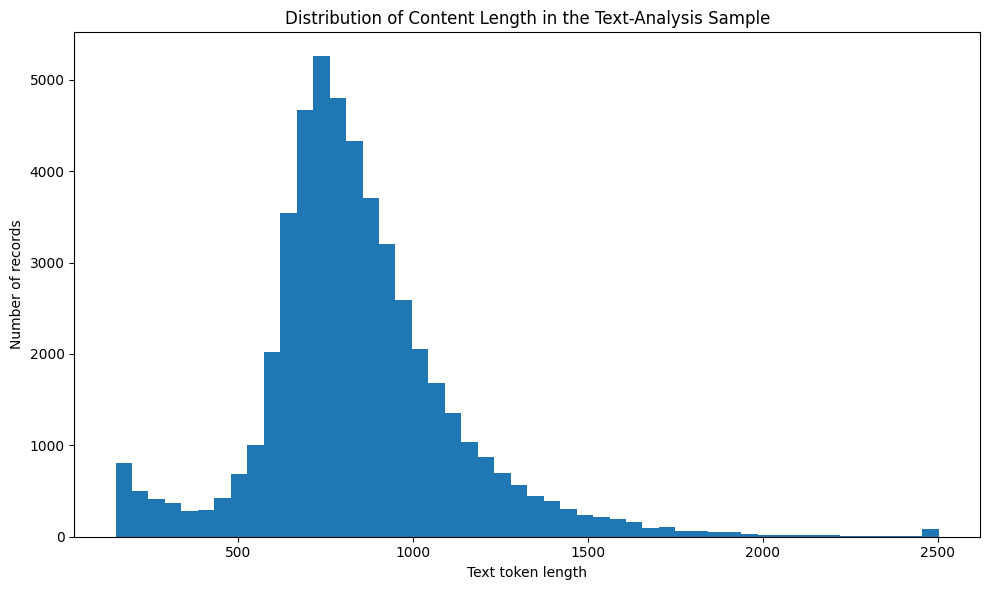

In [26]:
# 8.1 Token-length histogram from the controlled sample

sample_length_pd = text_sample_df.select("text_token_length").toPandas()

plt.figure(figsize=(10, 6))
plt.hist(sample_length_pd["text_token_length"].dropna(), bins=50)
plt.xlabel("Text token length")
plt.ylabel("Number of records")
plt.title("Distribution of Content Length in the Text-Analysis Sample")
plt.tight_layout()
plt.show()

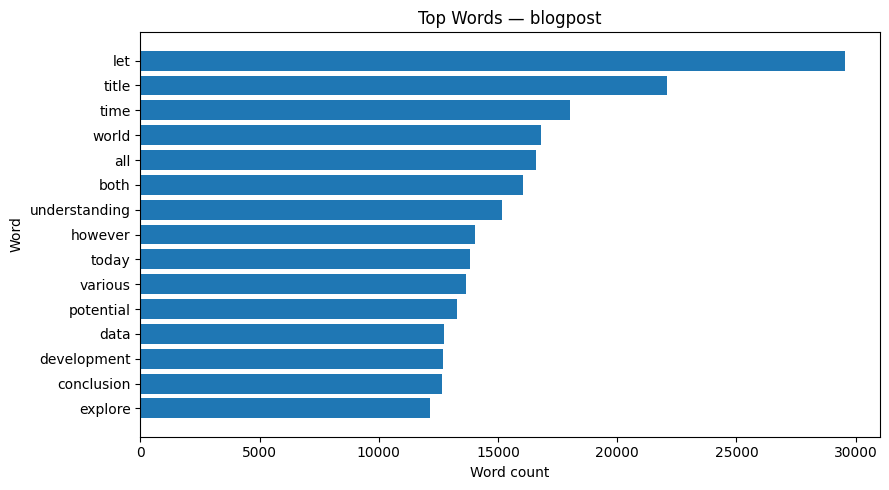

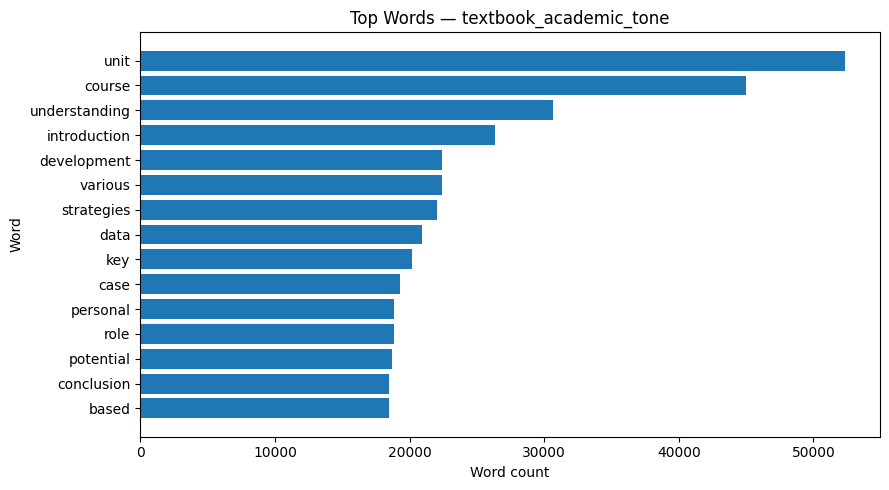

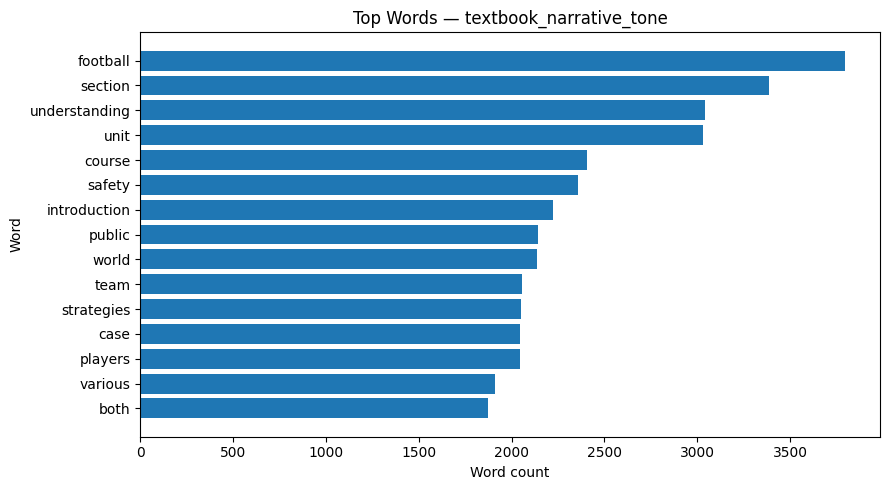

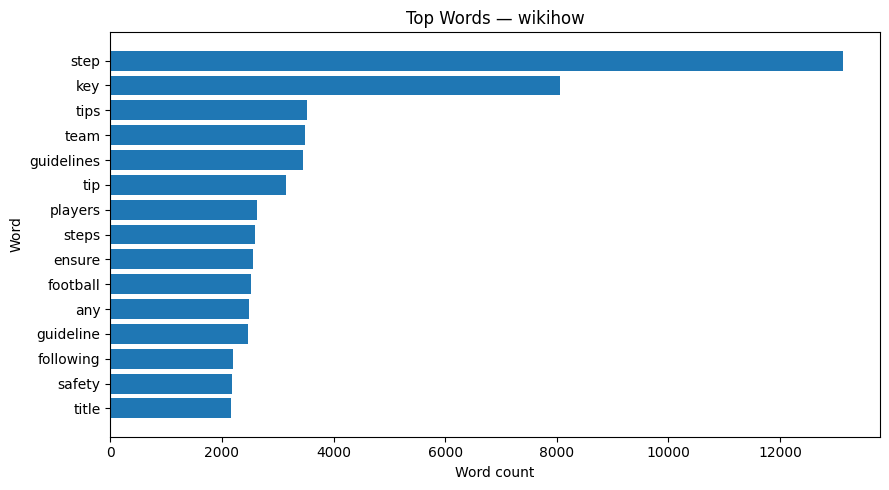

In [27]:
for fmt in top_words_pd["format"].drop_duplicates():
    plot = top_words_pd[top_words_pd["format"] == fmt].sort_values(
        "word_count", ascending=True
    )

    plt.figure(figsize=(9, 5))
    plt.barh(plot["word"], plot["word_count"])
    plt.xlabel("Word count")
    plt.ylabel("Word")
    plt.title(f"Top Words — {fmt}")
    plt.tight_layout()
    plt.show()

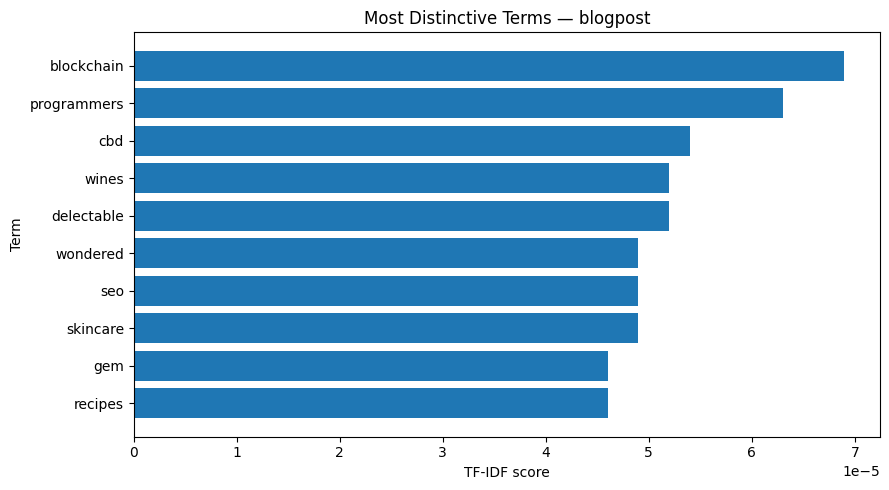

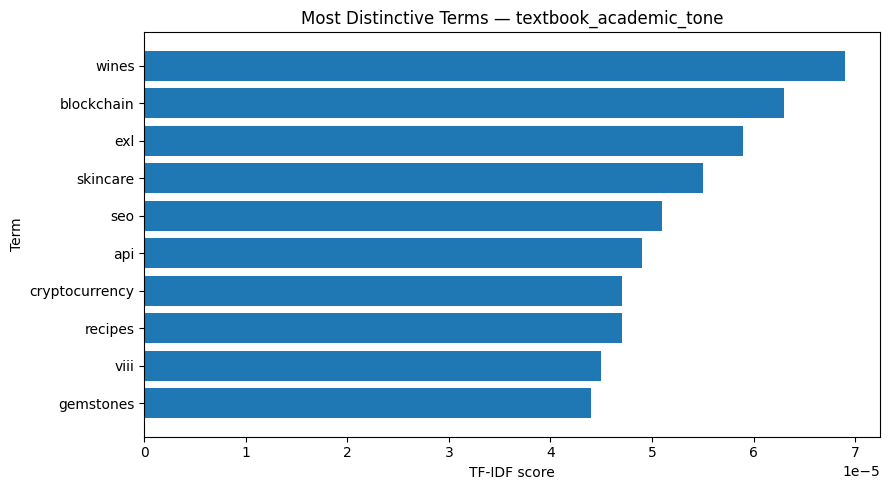

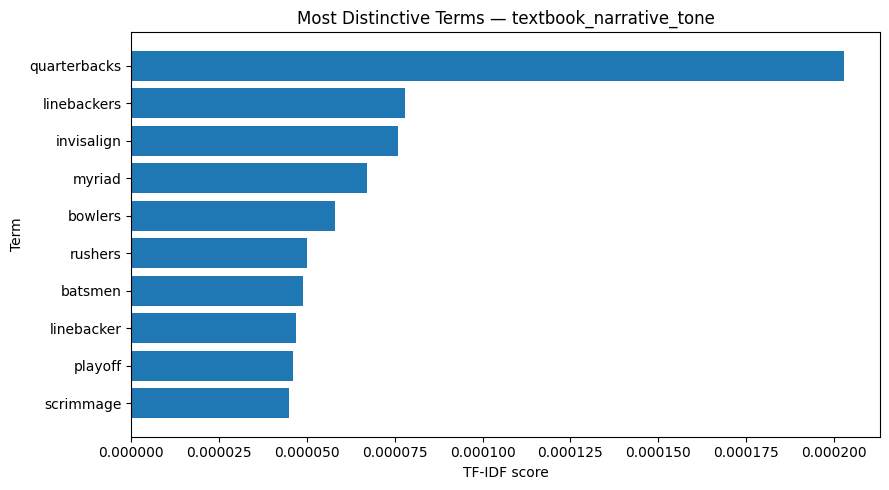

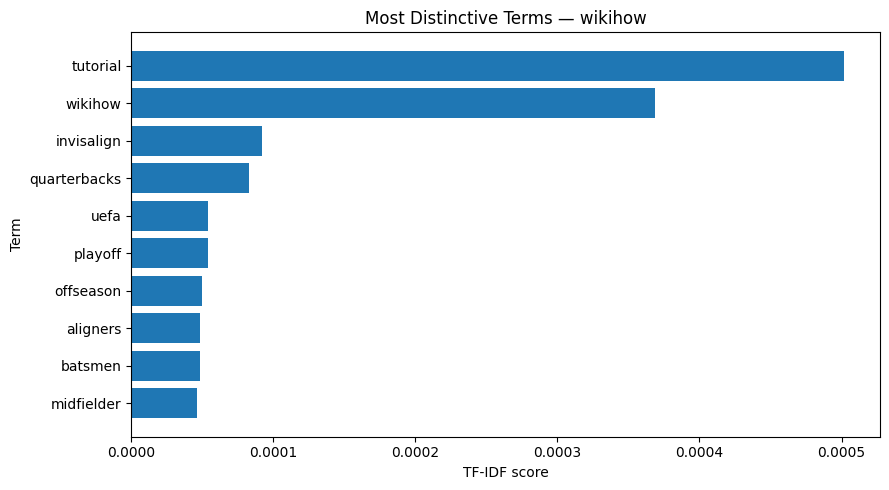

In [28]:
for fmt in top_tfidf_pd["format"].drop_duplicates():
    plot = top_tfidf_pd[top_tfidf_pd["format"] == fmt].sort_values(
        "tfidf", ascending=True
    )

    plt.figure(figsize=(9, 5))
    plt.barh(plot["word"], plot["tfidf"])
    plt.xlabel("TF-IDF score")
    plt.ylabel("Term")
    plt.title(f"Most Distinctive Terms — {fmt}")
    plt.tight_layout()
    plt.show()

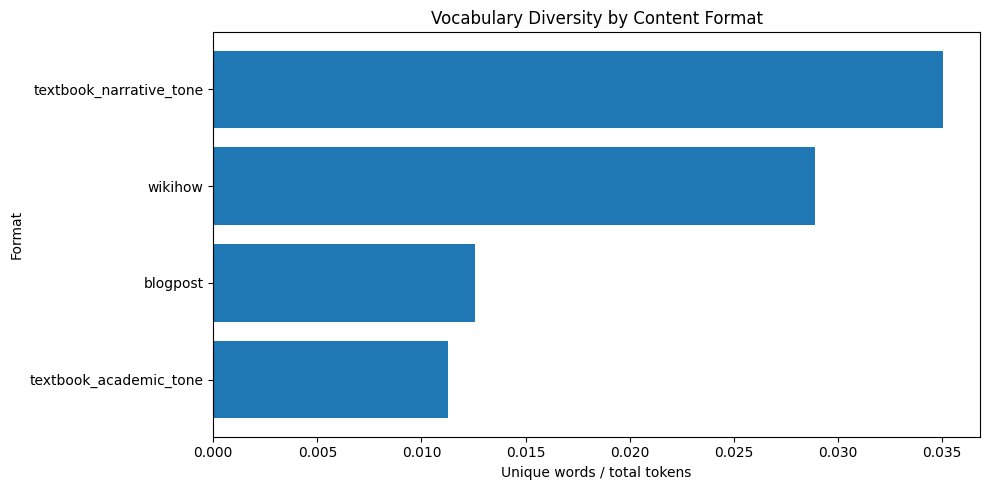

In [29]:
plot = vocab_pd.sort_values("vocabulary_diversity", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(plot["format"], plot["vocabulary_diversity"])
plt.xlabel("Unique words / total tokens")
plt.ylabel("Format")
plt.title("Vocabulary Diversity by Content Format")
plt.tight_layout()
plt.show()

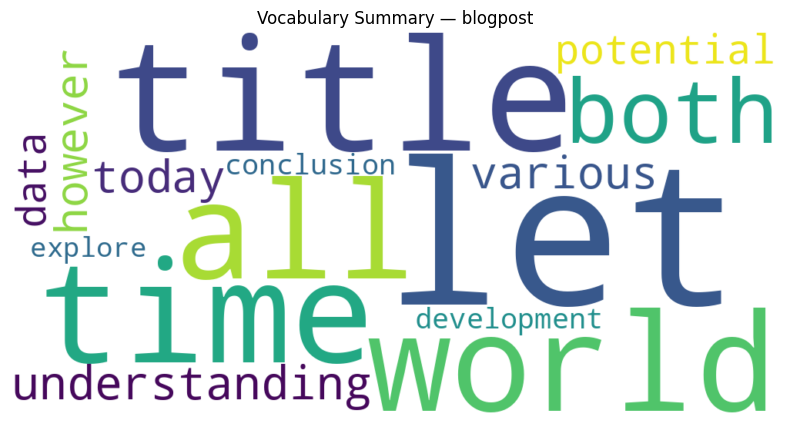

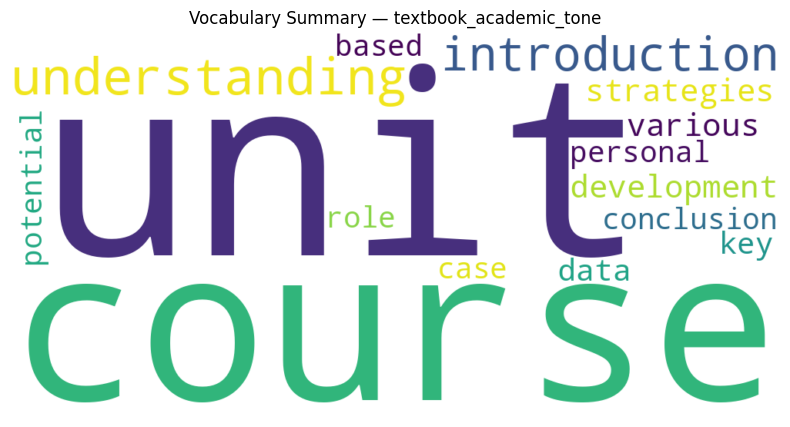

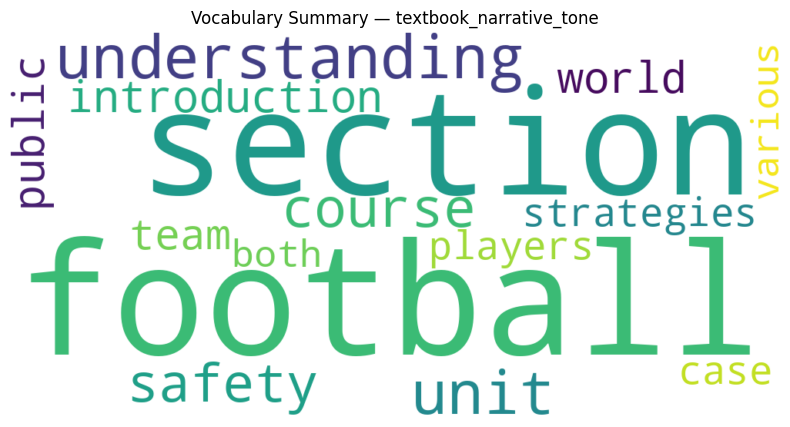

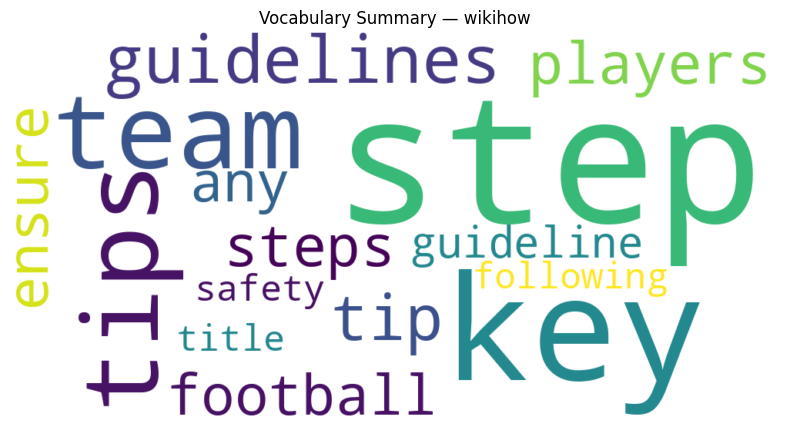

In [30]:
from wordcloud import WordCloud

for fmt in top_words_pd["format"].drop_duplicates():
    words = (
        top_words_pd[top_words_pd["format"] == fmt]
        .set_index("word")["word_count"]
        .to_dict()
    )

    wc = WordCloud(
        width=1000,
        height=500,
        background_color="white"
    ).generate_from_frequencies(words)

    plt.figure(figsize=(11, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Vocabulary Summary — {fmt}")
    plt.show()

In [31]:
# 11.1 Export compact result tables

PART2_ROOT = RESULTS_ROOT / "part2_text_analysis"
PART2_ROOT.mkdir(parents=True, exist_ok=True)

format_vocab_summary.toPandas().to_csv(
    PART2_ROOT / "format_vocabulary_summary.csv", index=False
)
top_words_by_format.toPandas().to_csv(
    PART2_ROOT / "top_words_by_format.csv", index=False
)
top_tfidf_by_format.toPandas().to_csv(
    PART2_ROOT / "top_tfidf_by_format.csv", index=False
)
audience_format_summary.toPandas().to_csv(
    PART2_ROOT / "audience_format_summary.csv", index=False
)

print(f"Saved compact Part 2 outputs to: {PART2_ROOT}")

Saved compact Part 2 outputs to: /content/cosmopedia_web_v1/results/part2_text_analysis
